# Vibrações Livres

Na aula de modelagem, apresentamos o oscilador harmônico

$$
m x'' + \gamma x' + kx = F(t)
$$

e fizemos algumas simulações numéricas dos casos livres (sem amortecimento, subamortecido, superamortecido), prometendo explicar depois de onde vinham esses comportamentos.

Agora que temos todas as ferramentas, vamos ver que cada regime físico corresponde, exatamente, a um dos três casos do discriminante que já estudamos.

## Os quatro regimes físicos

Sem força externa ($F(t)=0$), a equação característica de $mx''+\gamma x'+kx=0$ é

$$
mr^2+\gamma r+k=0, \qquad r = \frac{-\gamma\pm\sqrt{\gamma^2-4mk}}{2m}.
$$

O discriminante aqui é $\gamma^2-4mk$, e quem o controla é o amortecimento $\gamma$ (já que $m,k>0$ são fixos, propriedades do sistema).

Variando $\gamma$ de $0$ para valores bem grandes, cruzamos os três casos e, dentro do caso $\Delta<0$, ainda existe uma distinção física importante entre $\gamma=0$ e $\gamma>0$. Ao todo, quatro regimes:

| Regime | Condição | Raízes |
|---|---|---|
| **Não amortecido** | $\gamma=0$ | $r=\pm i\omega_0$, com $\omega_0=\sqrt{k/m}$ |
| **Subamortecido** | $0<\gamma<\gamma_{crit}$ | $r=\lambda\pm i\mu$, com $\lambda<0$ |
| **Crítico** | $\gamma=\gamma_{crit}$ | $r$ real, repetida |
| **Superamortecido** | $\gamma>\gamma_{crit}$ | $r_1\neq r_2$ reais |

em que $\gamma_{crit}=2\sqrt{mk}$ é o **amortecimento crítico**.

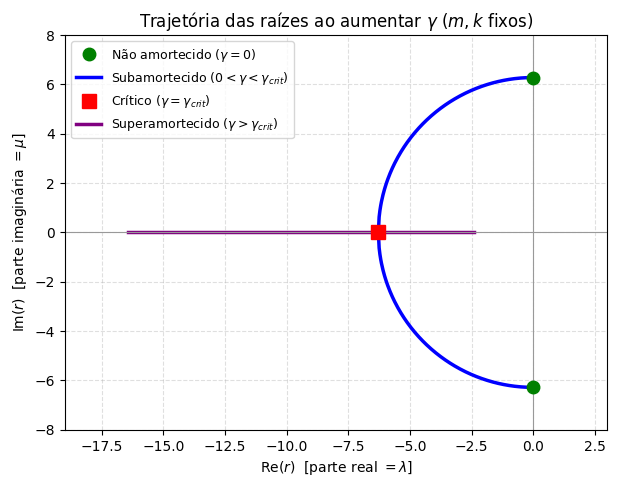

In [1]:
import numpy as np
import matplotlib.pyplot as plt

m, k = 1.0, (2*np.pi)**2
w0 = np.sqrt(k/m)
gamma_crit = 2*np.sqrt(k*m)

fig, ax = plt.subplots(figsize=(7, 7))

# Não amortecido: gamma = 0 (raízes puramente imaginárias)
ax.plot([0, 0], [w0, -w0], 'o', color='green', markersize=9,
        label='Não amortecido ($\\gamma=0$)', zorder=5)

# Subamortecido: 0 < gamma < gamma_crit -> semicírculo de raio w0
gamma_sub = np.linspace(0, gamma_crit, 200)
re = -gamma_sub/(2*m)
im = np.sqrt(np.clip(k/m - (gamma_sub/(2*m))**2, 0, None))
ax.plot(re, im, color='blue', linewidth=2.5, label='Subamortecido ($0<\\gamma<\\gamma_{crit}$)')
ax.plot(re, -im, color='blue', linewidth=2.5)

# Crítico: gamma = gamma_crit (raiz dupla real, em -w0)
ax.plot(-gamma_crit/(2*m), 0, 's', color='red', markersize=10,
        label='Crítico ($\\gamma=\\gamma_{crit}$)', zorder=5)

# Superamortecido: gamma > gamma_crit -> duas raízes reais se afastando
gamma_sup = np.linspace(gamma_crit, 1.5*gamma_crit, 200)
disc = np.sqrt((gamma_sup/(2*m))**2 - k/m)
r1 = -gamma_sup/(2*m) + disc
r2 = -gamma_sup/(2*m) - disc
ax.plot(r1, np.zeros_like(r1), color='purple', linewidth=2.5, label='Superamortecido ($\\gamma>\\gamma_{crit}$)')
ax.plot(r2, np.zeros_like(r2), color='purple', linewidth=2.5)

ax.axhline(0, color='0.6', linewidth=0.8)
ax.axvline(0, color='0.6', linewidth=0.8)
ax.set_xlabel(r'Re($r$)  [parte real $=\lambda$]')
ax.set_ylabel(r'Im($r$)  [parte imaginária $=\mu$]')
ax.set_title(r'Trajetória das raízes ao aumentar $\gamma$ ($m,k$ fixos)')
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim(-19, 3)
ax.set_ylim(-8, 8)
ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.4)
plt.show()

Esse tipo de figura mostrando como as raízes de uma equação se movem no plano complexo conforme um parâmetro varia é chamado de **diagrama de bifurcação** (ou 'lugar das raízes', em controle). Aqui, ele conta toda a história de uma vez: partindo de $\gamma=0$ no eixo imaginário (raízes puramente imaginárias, topo e base em verde), as raízes deslizam por um **semicírculo de raio $\omega_0$** conforme $\gamma$ cresce; repare que $\text{Re}(r)^2+\text{Im}(r)^2=\omega_0^2$ o tempo todo, então não é coincidência que a curva seja exatamente um semicírculo. À medida que $\gamma$ continua crescendo, as raízes complexas vão se aproximando até se encontrarem no eixo real, no ponto crítico (quadrado vermelho), exatamente quando $\gamma=\gamma_{crit}$. Depois disso, as duas raízes reais se separam ao longo do eixo real (roxo), uma indo em direção a $0$ e outra fugindo para $-\infty$.

O eixo real negativo corresponde a decaimento (a parte real de $r$ governa isso); o eixo imaginário é a fronteira onde não há decaimento nenhum. Vamos ver cada um desses regimes na prática.

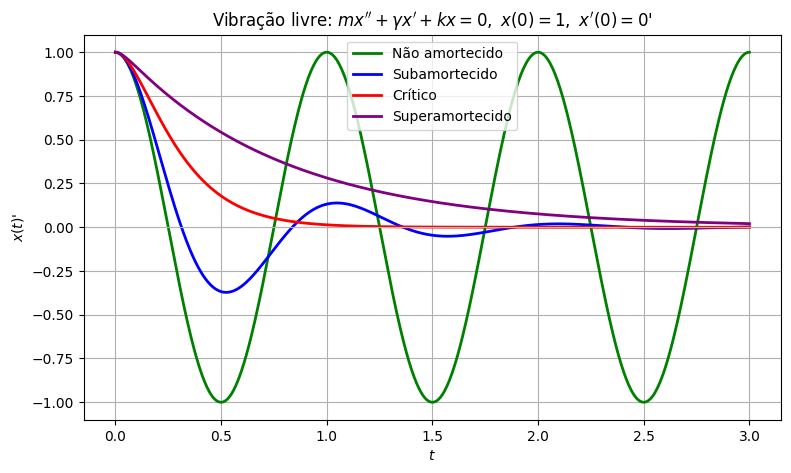

In [5]:
from scipy.integrate import odeint

def oscilador(estado, t, m, gamma, k):
    x, v = estado
    return [v, -(gamma/m)*v - (k/m)*x]

t = np.linspace(0, 3, 500)

casos = [
    (r"Não amortecido", 0.0, 'g'),
    (r"Subamortecido", 0.3*gamma_crit, 'b'),
    (r"Crítico", gamma_crit, 'r'),
    (r"Superamortecido", 2.5*gamma_crit, 'purple'),
]

plt.figure(figsize=(9, 5))
for label, gamma_, cor in casos:
    sol = odeint(oscilador, [1, 0], t, args=(m, gamma_, k))
    plt.plot(t, sol[:, 0], color=cor, linewidth=2, label=label)

plt.axhline(0, color='0.7', linewidth=0.8)
plt.title(r"Vibração livre: $mx''+\gamma x'+kx=0,\ x(0)=1,\ x'(0)=0$'")
plt.xlabel(r"$t$"); plt.ylabel(r"$x(t)$'")
plt.legend()
plt.grid(True)
plt.show()

Cada curva acima corresponde a uma das três fórmulas gerais que já conhecemos (lembrando que 'não amortecido' é só o caso particular $\lambda=0$ do subamortecido):

* **Não amortecido / Subamortecido:** $x(t) = e^{\lambda t}\big(c_1\cos\mu t + c_2\,\text{sen}\,\mu t\big)$, com $\lambda=-\gamma/(2m)$ e $\mu=\sqrt{k/m-\lambda^2}$.
* **Crítico:** $x(t) = (c_1+c_2t)\,e^{-\gamma t/(2m)}$.
* **Superamortecido:** $x(t) = c_1e^{r_1t}+c_2e^{r_2t}$, com $r_1,r_2$ as duas raízes reais.

## O caso subamortecido: uma onda disfarçada

A fórmula do caso subamortecido, $x(t)=e^{\lambda t}(c_1\cos\mu t+c_2\,\text{sen}\,\mu t)$, tem um problema estético: olhando para ela, não é nada óbvio que forma o gráfico vai ter. Uma combinação de cosseno e seno é... o quê, exatamente?

Existe uma identidade trigonométrica que resolve isso, e que vai ser muito útil agora e no resto do curso: **qualquer** combinação $C_1\cos(\omega t)+C_2\,\text{sen}(\omega t)$ pode ser reescrita como um único cosseno, só que deslocado (defasado) no tempo:

$$
C_1\cos(\omega t) + C_2\,\text{sen}(\omega t) = R\cos(\omega t-\delta),
$$

em que a **amplitude** $R$ e a **fase** $\delta$ dependem só de $C_1$ e $C_2$:

$$
R = \sqrt{C_1^2+C_2^2}, \qquad \tan\delta = \frac{C_2}{C_1} \quad (\text{com } \delta \text{ no quadrante certo}).
$$

*Prova rápida: expandindo o lado direito, $R\cos(\omega t-\delta)=R\cos\delta\cos\omega t + R\,\text{sen}\,\delta\,\text{sen}\,\omega t$. Comparando com o lado esquerdo, precisamos de $C_1=R\cos\delta$ e $C_2=R\,\text{sen}\,\delta$ — e daí saem as fórmulas de $R$ e $\delta$ acima.*

Vamos conferir com um exemplo numérico, e visualizar que as duas expressões realmente coincidem:

R = 5,  delta = 0.9273 rad
Diferença (deve ser 0): 0


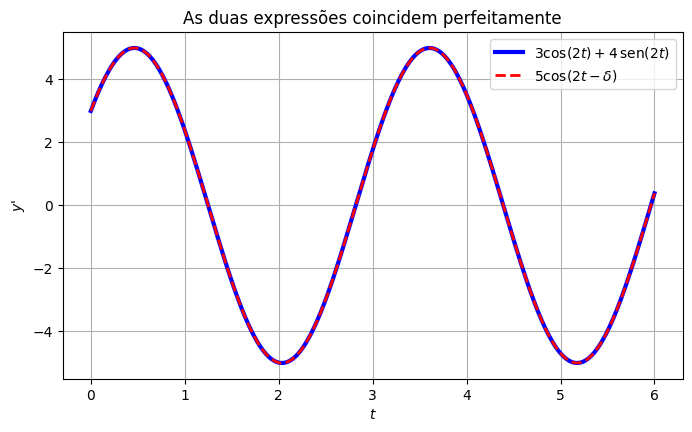

In [6]:
import sympy as sp

t_s, w_s = sp.symbols('t omega', real=True)
C1, C2 = 3, 4

R = sp.sqrt(C1**2 + C2**2)
delta = sp.atan2(C2, C1)

lado_esquerdo = C1*sp.cos(w_s*t_s) + C2*sp.sin(w_s*t_s)
lado_direito = R*sp.cos(w_s*t_s - delta)

print(f"R = {R},  delta = {float(delta):.4f} rad")
print(r"Diferença (deve ser 0):", sp.simplify(sp.expand_trig(lado_esquerdo - lado_direito)))

t_vals = np.linspace(0, 6, 300)
w_val = 2
le_vals = C1*np.cos(w_val*t_vals) + C2*np.sin(w_val*t_vals)
ld_vals = float(R)*np.cos(w_val*t_vals - float(delta))

plt.figure(figsize=(8, 4.5))
plt.plot(t_vals, le_vals, 'b', linewidth=3, label=r'$3\cos(2t)+4\,\mathrm{sen}(2t)$')
plt.plot(t_vals, ld_vals, 'r--', linewidth=2, label=r'$5\cos(2t-\delta)$')
plt.title(r"As duas expressões coincidem perfeitamente")
plt.xlabel(r"$t$"); plt.ylabel(r"$y$'")
plt.legend()
plt.grid(True)
plt.show()

Agora aplicamos isso à vibração subamortecida. Reaproveitando a equação $y''+4y'+13y=0$ (raízes $-2\pm3i$, então $\lambda=-2,\ \mu=3$) e escolhendo, por exemplo, $c_1=3,\ c_2=4$:

$$
y(t) = e^{-2t}(3\cos3t+4\,\text{sen}\,3t) = 5\,e^{-2t}\cos(3t-\delta), \qquad \delta=\arctan(4/3)\approx0{,}927.
$$

Agora sim, fica óbvio o formato do gráfico: é um cosseno de frequência $3$, com uma amplitude $5e^{-2t}$ que **encolhe exponencialmente** — exatamente a 'curva subamortecida' que já vimos simular lá em modelagem, agora com uma fórmula explícita para o envelope que a contém:

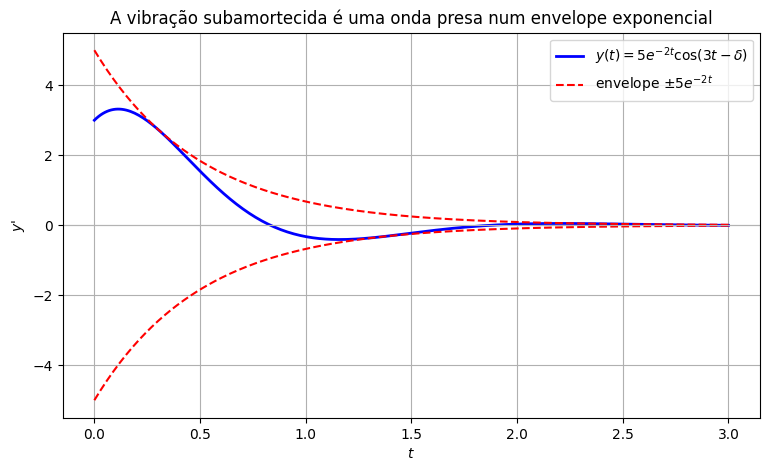

In [7]:
lam, mu = -2, 3
R_sub = 5
delta_sub = np.arctan2(4, 3)

t_vals = np.linspace(0, 3, 300)
y_vals = R_sub*np.exp(lam*t_vals)*np.cos(mu*t_vals - delta_sub)

plt.figure(figsize=(9, 5))
plt.plot(t_vals, y_vals, 'b', linewidth=2, label=r'$y(t)=5e^{-2t}\cos(3t-\delta)$')
plt.plot(t_vals, R_sub*np.exp(lam*t_vals), 'r--', linewidth=1.5, label=r'envelope $\pm5e^{-2t}$')
plt.plot(t_vals, -R_sub*np.exp(lam*t_vals), 'r--', linewidth=1.5)
plt.axhline(0, color='0.7', linewidth=0.8)
plt.title(r"A vibração subamortecida é uma onda presa num envelope exponencial")
plt.xlabel(r"$t$"); plt.ylabel(r"$y$'")
plt.legend()
plt.grid(True)
plt.show()

## O que vem a seguir

Agora entendemos completamente as vibrações **livres**: os quatro regimes, de onde vêm, e como enxergar o caso subamortecido como uma onda de amplitude decrescente.

Falta a parte mais interessante: o que acontece quando existe uma força externa, $F(t)\neq0$? É aí que vamos finalmente explicar, com todas as ferramentas prontas, o batimento e a ressonância que só simulamos numericamente lá em modelagem. Para isso, precisamos primeiro aprender a resolver equações **não homogêneas**, que são o próximo tema do curso.